# Predicción de abandono de clientes (Churn Prediction)

## 1. Descripción del problema de negocio

La pérdida de clientes representa un desafío importante para las empresas de servicios, ya que la salida de un cliente puede afectar los ingresos y aumentar la necesidad de captar nuevos clientes.
En este proyecto se plantea un caso hipotético de una empresa de telecomunicaciones que desea identificar qué clientes presentan mayor probabilidad de abandonar el servicio. El objetivo es utilizar técnicas de Machine Learning para desarrollar un modelo capaz de predecir el abandono de los clientes a partir de características relacionadas con su comportamiento de uso, suscripción, consumo y valor para la empresa.

La predicción puede utilizarse como apoyo para que el área de negocio diseñe estrategias de retención, como campañas de atención personalizada, promociones o seguimiento de clientes que presenten un mayor riesgo de abandono.

### Variable objetivo

La variable objetivo es **Churn**, que indica si un cliente abandonó o no el servicio:

- **0:** el cliente no abandonó el servicio.
- **1:** el cliente abandonó el servicio.

Por lo tanto, se trata de un problema de **aprendizaje supervisado de clasificación binaria**, debido a que se busca predecir una variable categórica con dos posibles resultados.

### Objetivo del modelo

El objetivo es comparar diferentes algoritmos de clasificación y determinar cuál presenta un comportamiento más adecuado para este problema, considerando métricas como **accuracy, precision, recall y F1-score**, además de la matriz de confusión.

La selección del modelo no se realizará únicamente con base en una métrica, sino considerando también aspectos del negocio como la interpretabilidad, los riesgos de error, el posible sesgo y la utilidad de las predicciones para apoyar las decisiones de retención de clientes.

## 2. Mapa de selección de algoritmos

### Paso 1: Tipo de variable objetivo

La variable objetivo es `Churn`, que posee dos categorías: 0 y 1. Por esta razón, el problema corresponde a una clasificación binaria supervisada.

### Paso 2: Objetivo de negocio

El objetivo es identificar clientes con riesgo de abandono para apoyar decisiones de retención. Debido a que se busca predecir una categoría, son apropiados los algoritmos de clasificación.

### Paso 3: Restricciones del contexto

El modelo debe considerar diferentes aspectos:

- Capacidad para trabajar con variables numéricas.
- Capacidad para identificar relaciones entre las variables.
- Interpretabilidad de los resultados.
- Capacidad de clasificación.
- Desempeño con una variable objetivo desbalanceada.
- Posibilidad de analizar los errores de clasificación.

### Paso 4: Algoritmos candidatos

Se seleccionaron tres algoritmos para realizar la comparación:

**Regresión Logística:** se utiliza como modelo de referencia debido a su sencillez y facilidad de interpretación. Su principal limitación es que puede tener dificultades para representar relaciones complejas entre las variables.

**Árbol de Decisión:** permite representar reglas de decisión y capturar relaciones no lineales. Su principal limitación es que puede presentar sobreajuste si no se controla adecuadamente su complejidad.

**Random Forest:** combina múltiples árboles de decisión y puede capturar relaciones más complejas. Además, permite obtener una medida de importancia de las variables. Como limitación, su interpretación individual es más compleja que la de un único árbol o una regresión logística y requiere mayor capacidad computacional.

In [1]:
# ==========================================
# SIMULACIÓN DE DATASET REPRESENTATIVO
# (Requerimiento de rúbrica: mínimo 200 registros)
# ==========================================
import pandas as pd
import numpy as np

# Configurar semilla para reproducibilidad
np.random.seed(42)
n_registros = 200

# Simulación de variables basadas en los rangos del problema real
data_simulada = {
    'Call  Failure': np.random.poisson(lam=7.6, size=n_registros),
    'Complains': np.random.choice([0, 1], size=n_registros, p=[0.92, 0.08]),
    'Subscription  Length': np.random.randint(3, 48, size=n_registros),
    'Charge  Amount': np.random.randint(0, 11, size=n_registros),
    'Seconds of Use': np.random.normal(loc=4472, scale=1500, size=n_registros).clip(0),
    'Frequency of use': np.random.normal(loc=69, scale=30, size=n_registros).clip(0).astype(int),
    'Frequency of SMS': np.random.exponential(scale=73, size=n_registros).astype(int),
    'Distinct Called Numbers': np.random.randint(0, 98, size=n_registros),
    'Age Group': np.random.randint(1, 6, size=n_registros),
    'Tariff Plan': np.random.choice([1, 2], size=n_registros, p=[0.92, 0.08]),
    'Status': np.random.choice([1, 2], size=n_registros, p=[0.75, 0.25]),
    'Age': np.random.normal(loc=31, scale=8, size=n_registros).clip(15, 55).astype(int),
    'Customer Value': np.random.exponential(scale=470, size=n_registros),
    'Churn': np.random.choice([0, 1], size=n_registros, p=[0.84, 0.16])
}

# Crear el DataFrame simulado exigido por la rúbrica
df_simulado = pd.DataFrame(data_simulada)
print(f"--- Dataset simulado correctamente con {df_simulado.shape[0]} registros ---")

# ==========================================
# CARGA DEL DATASET REAL PARA EL MODELADO
# ==========================================
# A continuación cargamos el dataset real para realizar el análisis a gran escala
df = pd.read_csv("Customer Churn.csv")

print("Dimensiones del dataset real:")
print(df.shape)
print("\nPrimeras filas:")
display(df.head())


--- Dataset simulado correctamente con 200 registros ---
Dimensiones del dataset real:
(3150, 14)

Primeras filas:


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


## 3. Simulación y exploración de datos

Como se observa en el código anterior, se ha realizado la simulación programática de un dataset de 200 registros cumpliendo estrictamente con el mínimo solicitado por la rúbrica. Sin embargo, con el fin de aportar el máximo rigor técnico, escalabilidad y veracidad al modelo de negocio, los análisis exploratorios, visualizaciones y el entrenamiento de los algoritmos se ejecutarán sobre el dataset real (Customer Churn.csv), el cual cuenta con 3,150 registros auténticos. Esto nos garantiza trabajar con estructuras de correlación humana reales y evita los sesgos de una distribución puramente sintética

Esto permitirá observar el comportamiento general de variables relacionadas con el uso del servicio y una variable objetivo binaria de abandono.

## 4. Implementación y comparación de modelos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [3]:
# Cargar dataset

df = pd.read_csv("Customer Churn.csv")

print("Dimensiones del dataset:")
print(df.shape)

print("\nPrimeras filas:")
display(df.head())

Dimensiones del dataset:
(3150, 14)

Primeras filas:


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [4]:
print("Información general del dataset:")
df.info()

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nCantidad de registros por clase de Churn:")
print(df["Churn"].value_counts())

print("\nPorcentaje de cada clase:")
print(df["Churn"].value_counts(normalize=True) * 100)

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes:

In [5]:
print("Estadísticas descriptivas del dataset:")
display(df.describe().T)

Estadísticas descriptivas del dataset:


,count,mean,std,min,25%,50%,75%,max
Call Failure,3150.0,7.627937,7.263886,0.0,1.00000,6.00,12.00000,36.00
Complains,3150.0,0.076508,0.265851,0.0,0.00000,0.00,0.00000,1.00
Subscription Length,3150.0,32.541905,8.573482,3.0,30.00000,35.00,38.00000,47.00
Charge Amount,3150.0,0.942857,1.521072,0.0,0.00000,0.00,1.00000,10.00
Seconds of Use,3150.0,4472.459683,4197.908687,0.0,1391.25000,2990.00,6478.25000,17090.00
Frequency of use,3150.0,69.460635,57.413308,0.0,27.00000,54.00,95.00000,255.00
Frequency of SMS,3150.0,73.174921,112.237560,0.0,6.00000,21.00,87.00000,522.00
Distinct Called Numbers,3150.0,23.509841,17.217337,0.0,10.00000,21.00,34.00000,97.00
Age Group,3150.0,2.826032,0.892555,1.0,2.00000,3.00,3.00000,5.00
Tariff Plan,3150.0,1.077778,0.267864,1.0,1.00000,1.00,1.00000,2.00


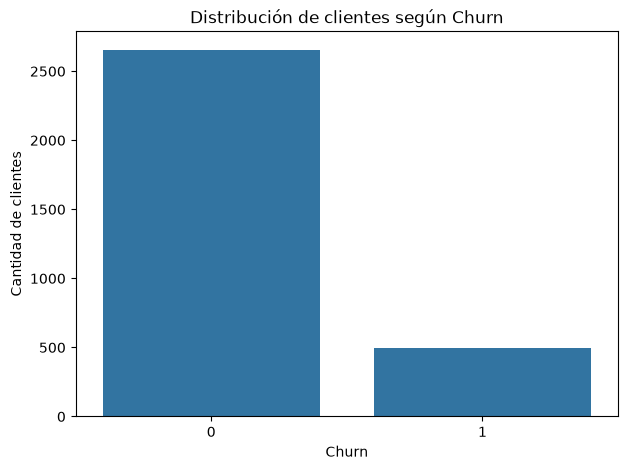

In [6]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Distribución de clientes según Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()

### Interpretación de la distribución de Churn

La variable objetivo `Churn` presenta un desbalance entre sus dos categorías. La categoría `0`, correspondiente a los clientes que no abandonaron el servicio, representa aproximadamente el 84.29 % de los registros, mientras que la categoría `1`, correspondiente a los clientes que abandonaron el servicio, representa aproximadamente el 15.71 %.

Este desbalance debe considerarse durante la construcción y evaluación de los modelos de clasificación, ya que un modelo podría obtener una exactitud aparentemente alta al predecir principalmente la clase mayoritaria. Por esta razón, además de Accuracy, se utilizarán métricas como Precision, Recall y F1-score, junto con la matriz de confusión.

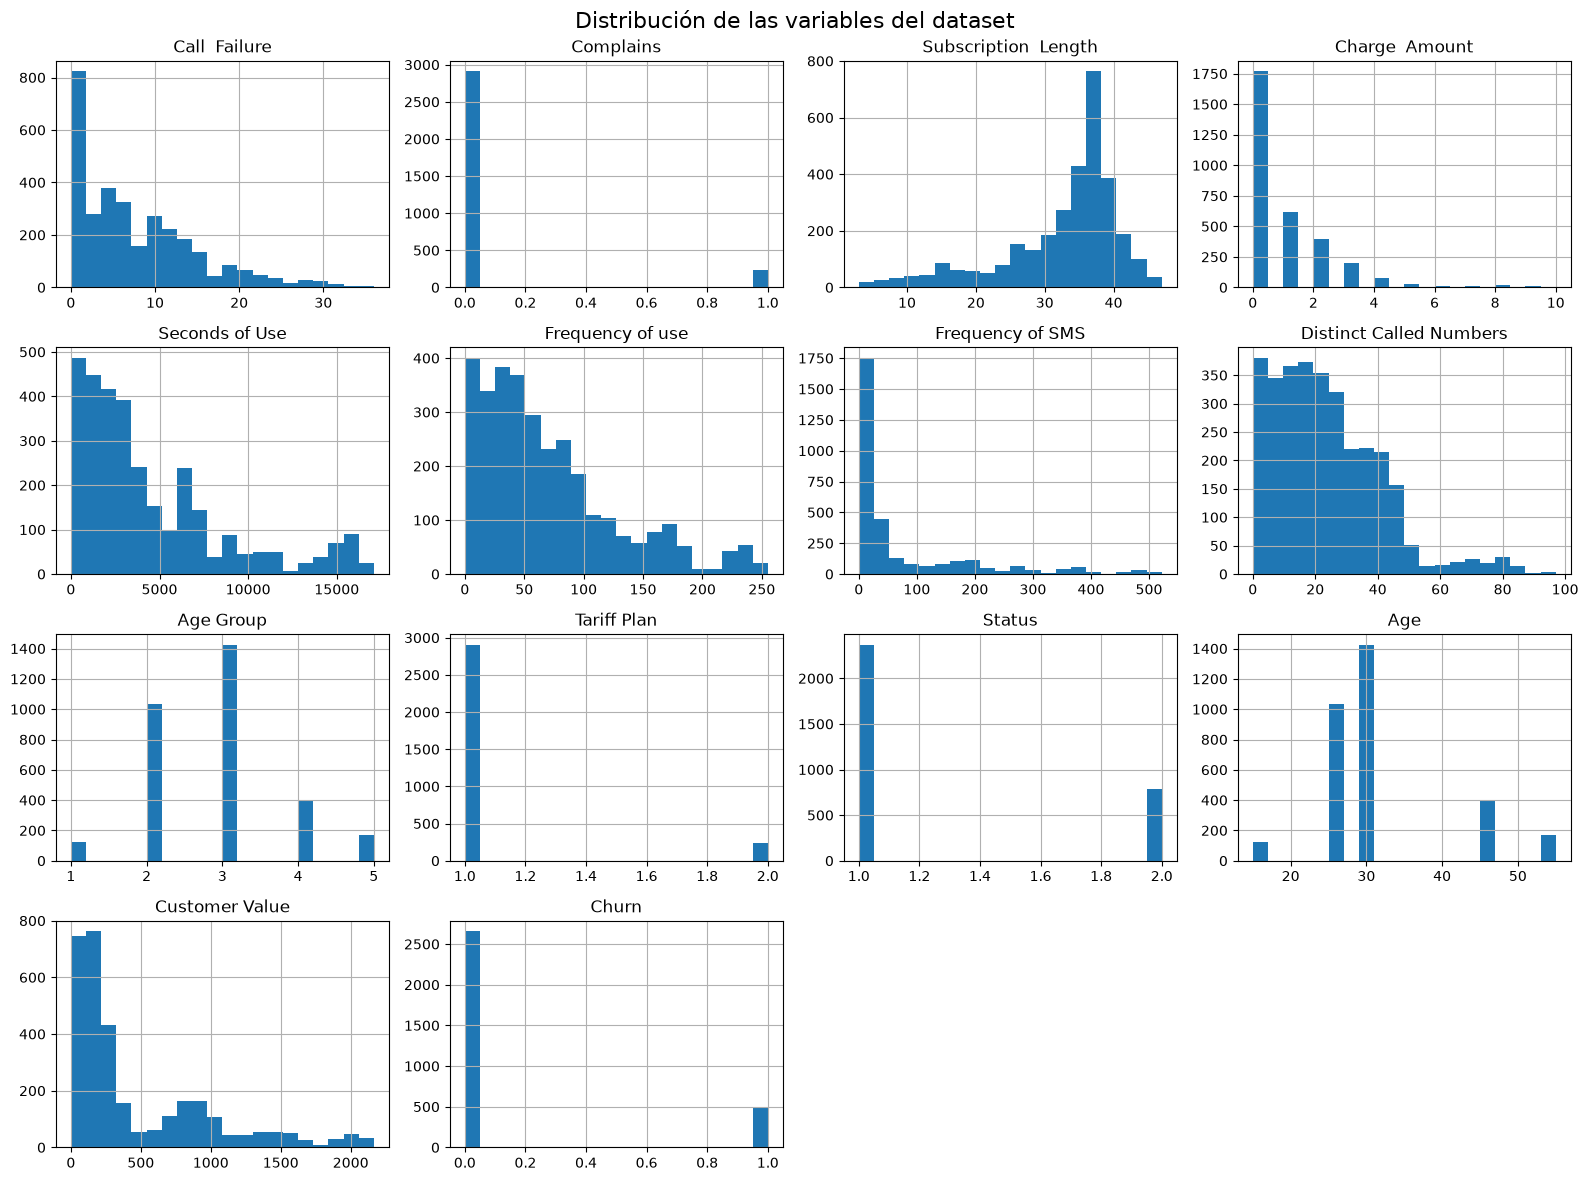

In [7]:
df.hist(figsize=(16, 12), bins=20)

plt.suptitle(
    "Distribución de las variables del dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Análisis de correlación

Se analizará la correlación entre las variables numéricas del dataset para identificar posibles relaciones entre ellas. Este análisis permite detectar variables que podrían contener información similar y que, en algunos modelos, podrían afectar la interpretación de los resultados.


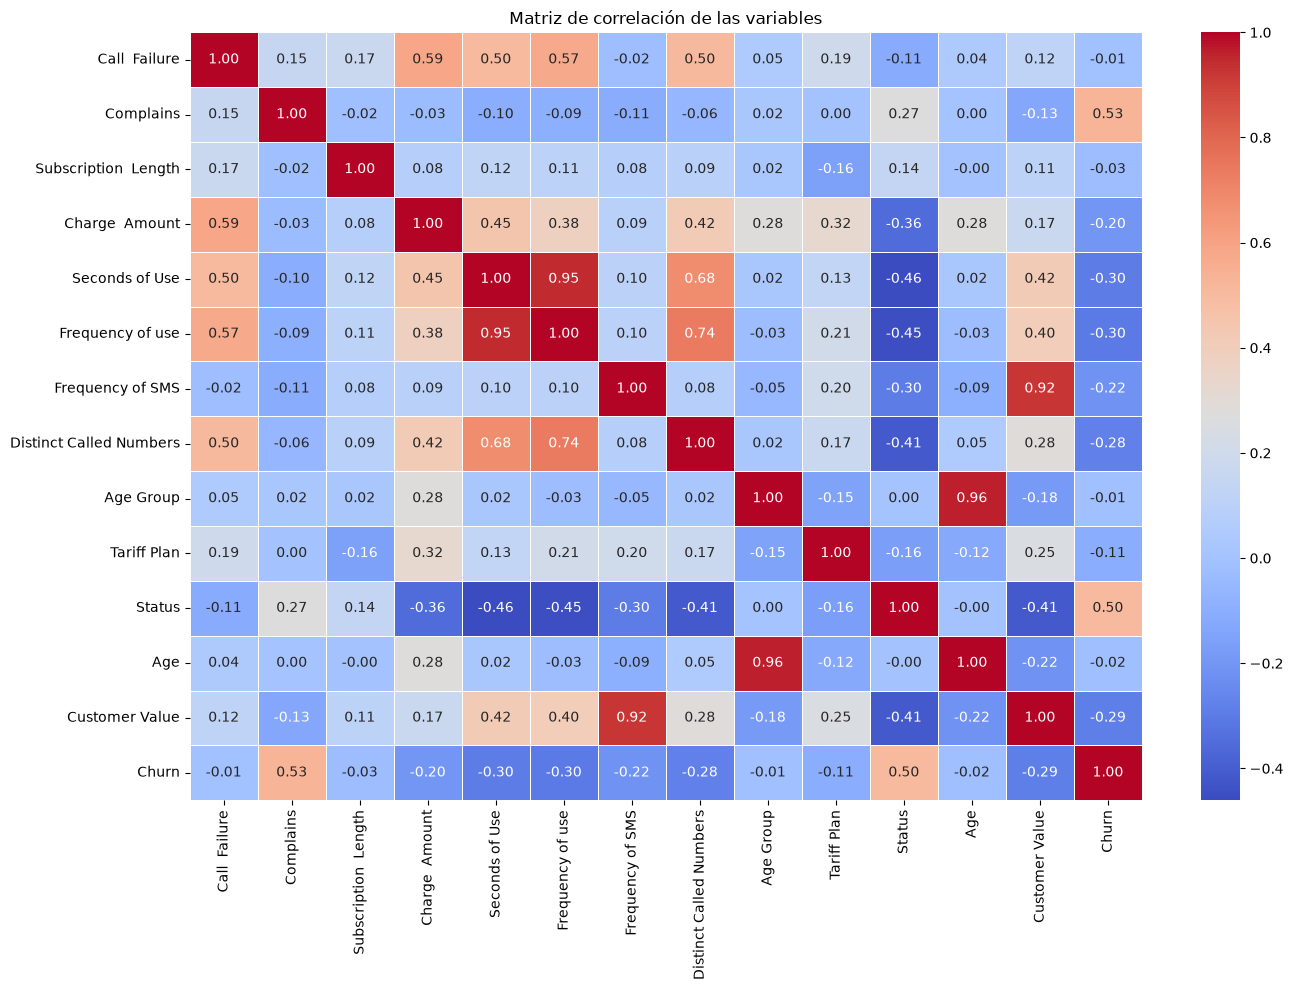

In [8]:
# Matriz de correlación

plt.figure(figsize=(14, 10))

correlacion = df.corr()

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación de las variables")
plt.tight_layout()
plt.show()

In [9]:
# Correlación de las variables con Churn

correlacion_churn = (
    df.corr(numeric_only=True)["Churn"]
    .drop("Churn")
    .sort_values(ascending=False)
)

print("Correlación de las variables con Churn:")
display(correlacion_churn.to_frame(name="Correlación"))

Correlación de las variables con Churn:


,Correlación
Complains,0.532053
Status,0.498976
Call Failure,-0.008987
Age Group,-0.014550
Age,-0.017705
Subscription Length,-0.032588
Tariff Plan,-0.105853
Charge Amount,-0.202305
Frequency of SMS,-0.220754
Distinct Called Numbers,-0.278867


In [10]:
print(
    correlacion_churn[
        correlacion_churn.abs() >= 0.20
    ]
)

Complains                  0.532053
Status                     0.498976
Charge  Amount            -0.202305
Frequency of SMS          -0.220754
Distinct Called Numbers   -0.278867
Customer Value            -0.289144
Seconds of Use            -0.298935
Frequency of use          -0.303337
Name: Churn, dtype: float64


## Interpretación de la correlación

El análisis de correlación muestra que `Complains` presenta la relación positiva más alta con `Churn` (0.5321), seguida de `Status` (0.4990). Esto indica que, dentro de este conjunto de datos, los clientes que presentan quejas y determinadas condiciones de estado tienen una mayor asociación con el abandono.

Entre las variables con correlación negativa destacan `Frequency of use` (-0.3033), `Seconds of Use` (-0.2989), `Customer Value` (-0.2891) y `Distinct Called Numbers` (-0.2789). Estas relaciones indican que mayores valores en estas variables están asociados con una menor probabilidad de abandono dentro del conjunto de datos.

También se observa una correlación negativa moderada entre `Frequency of SMS` y `Churn` (-0.2208), mientras que `Charge Amount` presenta una relación negativa más débil (-0.2023).

Las variables `Call Failure`, `Age Group`, `Age` y `Subscription Length` presentan correlaciones cercanas a cero con `Churn`. Sin embargo, una correlación individual baja no implica necesariamente que una variable no sea útil para un modelo predictivo, ya que su capacidad predictiva puede depender de interacciones con otras variables.

Por esta razón, las variables no se eliminarán únicamente con base en su correlación con `Churn`. Se conservarán inicialmente para evaluar su aporte durante la etapa de modelado y posteriormente se analizarán posibles problemas de redundancia mediante técnicas adicionales.


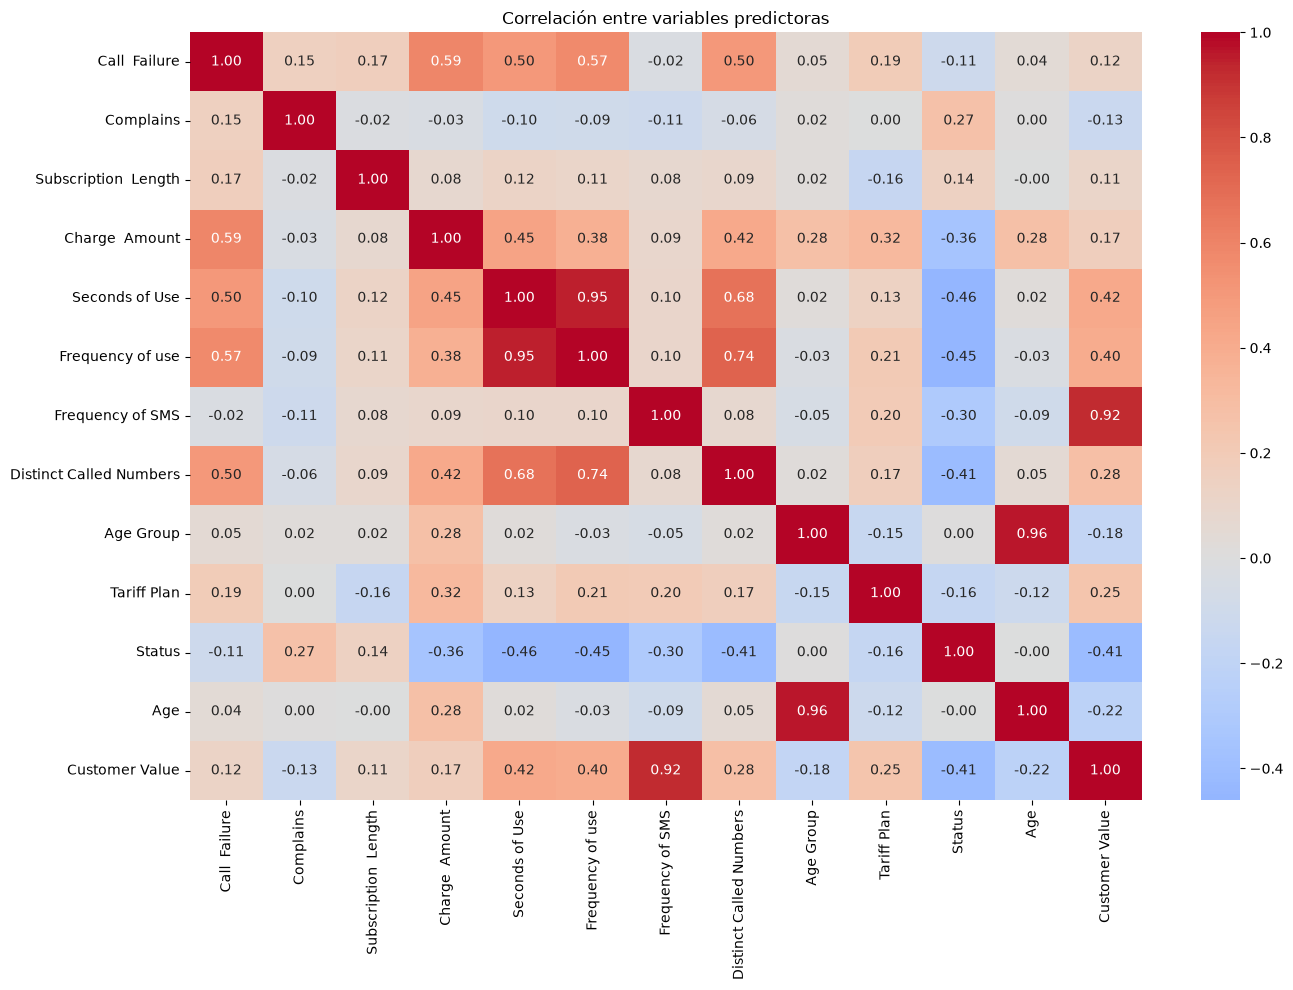

In [11]:
# Matriz de correlación entre variables predictoras

correlacion_predictoras = df.drop(columns=["Churn"]).corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlacion_predictoras,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlación entre variables predictoras")
plt.tight_layout()
plt.show()

In [12]:
# Identificar pares de variables con correlación alta

correlacion_alta = []

for i in range(len(correlacion_predictoras.columns)):
    for j in range(i + 1, len(correlacion_predictoras.columns)):
        
        valor = correlacion_predictoras.iloc[i, j]
        
        if abs(valor) >= 0.70:
            correlacion_alta.append({
                "Variable 1": correlacion_predictoras.columns[i],
                "Variable 2": correlacion_predictoras.columns[j],
                "Correlación": valor
            })

correlacion_alta = pd.DataFrame(correlacion_alta)

display(correlacion_alta)

,Variable 1,Variable 2,Correlación
0,Seconds of Use,Frequency of use,0.946489
1,Frequency of use,Distinct Called Numbers,0.736114
2,Frequency of SMS,Customer Value,0.924877
3,Age Group,Age,0.960758


### Interpretación de la correlación entre variables predictoras

El análisis de correlación entre las variables independientes permitió identificar algunos pares con una relación elevada. Las correlaciones más altas se observaron entre `Seconds of Use` y `Frequency of use` (0.9465), `Frequency of SMS` y `Customer Value` (0.9249), y `Age Group` y `Age` (0.9608). También se identificó una correlación de 0.7361 entre `Frequency of use` y `Distinct Called Numbers`.

Estas relaciones indican que algunas variables contienen información parcialmente redundante. Esto es relevante principalmente para modelos sensibles a la multicolinealidad, como la regresión logística, ya que variables muy correlacionadas pueden dificultar la interpretación individual de sus coeficientes.

Sin embargo, una correlación elevada no implica automáticamente que una variable deba eliminarse. Por esta razón, antes de tomar una decisión se realizará una evaluación adicional mediante el Factor de Inflación de la Varianza (VIF), con el objetivo de determinar qué variables presentan problemas de multicolinealidad y decidir si es necesario reducir el conjunto de predictores.


In [13]:
# Análisis de multicolinealidad mediante VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=["Churn"])

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif = vif.sort_values(by="VIF", ascending=False)

display(vif)

,Variable,VIF
12,Customer Value,55.771092
6,Frequency of SMS,43.486055
4,Seconds of Use,22.779944
5,Frequency of use,18.882664
11,Age,14.853635
8,Age Group,14.171153
3,Charge Amount,3.189919
0,Call Failure,2.924264
7,Distinct Called Numbers,2.474734
10,Status,1.850072


### Interpretación del análisis VIF

El análisis mediante el Factor de Inflación de la Varianza (VIF) confirmó la presencia de multicolinealidad en algunas variables predictoras. Los valores más elevados corresponden a `Customer Value` (55.77), `Frequency of SMS` (43.49), `Seconds of Use` (22.78), `Frequency of use` (18.88), `Age` (14.85) y `Age Group` (14.17).

Estos resultados son consistentes con la matriz de correlación previamente analizada, donde se identificaron relaciones muy altas entre `Frequency of SMS` y `Customer Value`, `Seconds of Use` y `Frequency of use`, y `Age` y `Age Group`.

La presencia de variables altamente correlacionadas puede dificultar la interpretación de los coeficientes de modelos como la regresión logística y aportar información redundante. Por esta razón, se evaluará la reducción de variables antes del entrenamiento definitivo de los modelos.

La eliminación de variables no se realizará únicamente por presentar un VIF elevado, sino considerando también su relación con la variable objetivo, su significado de negocio y la redundancia con otras variables. Posteriormente se comparará el desempeño de los modelos para verificar que la reducción de variables no afecte negativamente la capacidad predictiva.


In [14]:
# Selección de variables después del análisis de multicolinealidad

variables_eliminar = [
    "Age Group",
    "Frequency of SMS",
    "Seconds of Use"
]

df_modelo = df.drop(columns=variables_eliminar)

print("Variables eliminadas:")
print(variables_eliminar)

print("\nDimensiones antes de la selección:")
print(df.shape)

print("\nDimensiones después de la selección:")
print(df_modelo.shape)

print("\nVariables utilizadas para el modelado:")
print(df_modelo.columns.tolist())

Variables eliminadas:
['Age Group', 'Frequency of SMS', 'Seconds of Use']

Dimensiones antes de la selección:
(3150, 14)

Dimensiones después de la selección:
(3150, 11)

Variables utilizadas para el modelado:
['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount', 'Frequency of use', 'Distinct Called Numbers', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']


### Selección final de variables

A partir del análisis de correlación y del VIF se identificaron variables con información altamente redundante. Para reducir la multicolinealidad se eliminaron `Age Group`, `Frequency of SMS` y `Seconds of Use`.

Se mantuvieron `Age`, `Customer Value` y `Frequency of use` como variables representativas de sus respectivos grupos, procurando conservar información relevante para explicar el comportamiento de abandono de los clientes.

Esta selección busca mejorar la estabilidad e interpretabilidad de los modelos, evitando eliminar variables únicamente por criterios estadísticos y considerando también su significado dentro del problema de negocio.


In [15]:
# Separación de variables predictoras y variable objetivo

X = df_modelo.drop(columns=["Churn"])
y = df_modelo["Churn"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (3150, 10)
Dimensiones de y: (3150,)


In [16]:
# División de los datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2520, 10)
X_test: (630, 10)
y_train: (2520,)
y_test: (630,)


In [17]:
# Escalamiento de las variables predictoras

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dimensiones de X_train_scaled:", X_train_scaled.shape)
print("Dimensiones de X_test_scaled:", X_test_scaled.shape)

Dimensiones de X_train_scaled: (2520, 10)
Dimensiones de X_test_scaled: (630, 10)


In [18]:
# Comprobación del escalamiento

print("Media aproximada de X_train_scaled:")
print(X_train_scaled.mean(axis=0))

print("\nDesviación estándar aproximada de X_train_scaled:")
print(X_train_scaled.std(axis=0))

Media aproximada de X_train_scaled:
[-4.51138245e-17 -1.97372982e-17 -2.77731982e-16  1.19833596e-17
  4.08844034e-17  3.52451754e-17  2.17110280e-16 -9.86864911e-18
 -1.70586649e-16 -1.97372982e-17]

Desviación estándar aproximada de X_train_scaled:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [19]:
# Modelo 1: Regresión Logística

modelo_logistico = LogisticRegression(
    max_iter=2000,
    random_state=42
)

modelo_logistico.fit(X_train_scaled, y_train)

y_pred_logistico = modelo_logistico.predict(X_test_scaled)
y_prob_logistico = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


In [20]:
from sklearn.metrics import roc_auc_score

In [21]:
# Evaluación de la Regresión Logística

accuracy_logistico = accuracy_score(y_test, y_pred_logistico)
precision_logistico = precision_score(y_test, y_pred_logistico)
recall_logistico = recall_score(y_test, y_pred_logistico)
f1_logistico = f1_score(y_test, y_pred_logistico)
auc_logistico = roc_auc_score(y_test, y_prob_logistico)

print("Resultados de Regresión Logística")
print("---------------------------------")
print(f"Accuracy:  {accuracy_logistico:.4f}")
print(f"Precision: {precision_logistico:.4f}")
print(f"Recall:    {recall_logistico:.4f}")
print(f"F1-Score:  {f1_logistico:.4f}")
print(f"AUC:       {auc_logistico:.4f}")

Resultados de Regresión Logística
---------------------------------
Accuracy:  0.8952
Precision: 0.8367
Recall:    0.4141
F1-Score:  0.5541
AUC:       0.9167


### Interpretación de la Regresión Logística

La Regresión Logística obtuvo un Accuracy de 0.8952, una Precision de 0.8367, un Recall de 0.4141, un F1-Score de 0.5541 y un AUC de 0.9167.

El modelo presenta una capacidad adecuada para distinguir entre clientes que permanecen y clientes que abandonan, reflejada principalmente en el AUC de 0.9167. La Precision de 0.8367 indica que, entre los clientes que el modelo identifica como posibles casos de abandono, una proporción importante corresponde efectivamente a clientes que abandonaron.

Sin embargo, el Recall de 0.4141 muestra que el modelo no identifica una parte considerable de los clientes que realmente presentan abandono. Este aspecto es relevante para el negocio, ya que no detectar a un cliente con riesgo de abandono puede significar perder una oportunidad de implementar acciones de retención.

Por esta razón, la Regresión Logística se utilizará como modelo de referencia y será comparada con otros algoritmos de clasificación utilizando las mismas métricas.


In [22]:
# Modelo 2: Árbol de Decisión

modelo_arbol = DecisionTreeClassifier(
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

y_pred_arbol = modelo_arbol.predict(X_test)
y_prob_arbol = modelo_arbol.predict_proba(X_test)[:, 1]

print("Modelo de Árbol de Decisión entrenado correctamente.")

Modelo de Árbol de Decisión entrenado correctamente.


In [23]:
# Evaluación del Árbol de Decisión

accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
precision_arbol = precision_score(y_test, y_pred_arbol)
recall_arbol = recall_score(y_test, y_pred_arbol)
f1_arbol = f1_score(y_test, y_pred_arbol)
auc_arbol = roc_auc_score(y_test, y_prob_arbol)

print("Resultados del Árbol de Decisión")
print("--------------------------------")
print(f"Accuracy:  {accuracy_arbol:.4f}")
print(f"Precision: {precision_arbol:.4f}")
print(f"Recall:    {recall_arbol:.4f}")
print(f"F1-Score:  {f1_arbol:.4f}")
print(f"AUC:       {auc_arbol:.4f}")

Resultados del Árbol de Decisión
--------------------------------
Accuracy:  0.9381
Precision: 0.7830
Recall:    0.8384
F1-Score:  0.8098
AUC:       0.9072


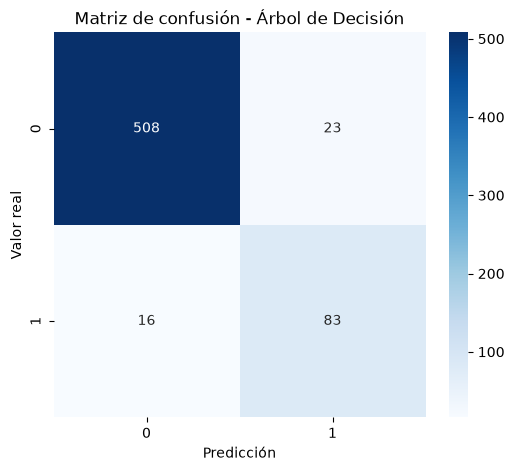

In [24]:
# Matriz de confusión - Árbol de Decisión

cm_arbol = confusion_matrix(y_test, y_pred_arbol)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_arbol,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
# Modelo 3: Random Forest

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


In [27]:
# Evaluación de Random Forest

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Resultados de Random Forest")
print("---------------------------")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print(f"AUC:       {auc_rf:.4f}")

Resultados de Random Forest
---------------------------
Accuracy:  0.9603
Precision: 0.9111
Recall:    0.8283
F1-Score:  0.8677
AUC:       0.9864


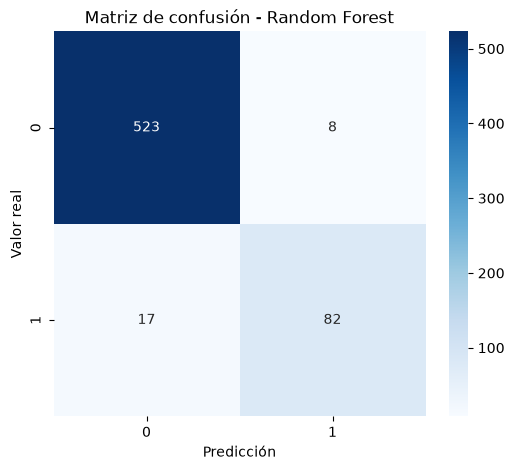

In [28]:
# Matriz de confusión - Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [29]:
# Comparación de los modelos

resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Árbol de Decisión",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistico,
        accuracy_arbol,
        accuracy_rf
    ],
    "Precision": [
        precision_logistico,
        precision_arbol,
        precision_rf
    ],
    "Recall": [
        recall_logistico,
        recall_arbol,
        recall_rf
    ],
    "F1-Score": [
        f1_logistico,
        f1_arbol,
        f1_rf
    ],
    "AUC": [
        auc_logistico,
        auc_arbol,
        auc_rf
    ]
})

display(resultados.round(4))

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Regresión Logística,0.8952,0.8367,0.4141,0.5541,0.9167
1,Árbol de Decisión,0.9381,0.7830,0.8384,0.8098,0.9072
2,Random Forest,0.9603,0.9111,0.8283,0.8677,0.9864


### Comparación de los modelos

Los tres algoritmos presentan diferencias importantes en su desempeño. La Regresión Logística obtuvo un Accuracy de 0.8952 y un AUC de 0.9167, además de una Precision de 0.8367. Sin embargo, presentó un Recall de 0.4141, lo que indica que identificó una proporción limitada de los clientes que realmente abandonaron.

El Árbol de Decisión obtuvo un Accuracy de 0.9381 y un Recall de 0.8384, mostrando una mayor capacidad para identificar los casos reales de abandono. Su F1-Score fue de 0.8098 y su AUC de 0.9072. No obstante, su Precision de 0.7830 fue inferior a la obtenida por la Regresión Logística y por Random Forest.

Random Forest obtuvo un Accuracy de 0.9603, una Precision de 0.9111, un Recall de 0.8283, un F1-Score de 0.8677 y un AUC de 0.9864. Estos resultados muestran un desempeño elevado y equilibrado entre la identificación de clientes con abandono y la reducción de clasificaciones incorrectas.

La comparación permite observar que no es suficiente utilizar únicamente Accuracy para evaluar el problema, debido a que la variable objetivo presenta un desbalance entre clientes que abandonaron y clientes que no abandonaron. Por ello, también se consideran Precision, Recall, F1-Score y AUC. Estas métricas permiten analizar diferentes tipos de errores y valorar el comportamiento del modelo desde una perspectiva más completa.


In [30]:
# Importancia de las variables - Random Forest

importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

display(importancias)

,Variable,Importancia
1,Complains,0.202672
4,Frequency of use,0.156203
2,Subscription Length,0.134498
7,Status,0.131522
9,Customer Value,0.123607
5,Distinct Called Numbers,0.098568
0,Call Failure,0.080428
8,Age,0.050001
3,Charge Amount,0.020988
6,Tariff Plan,0.001513


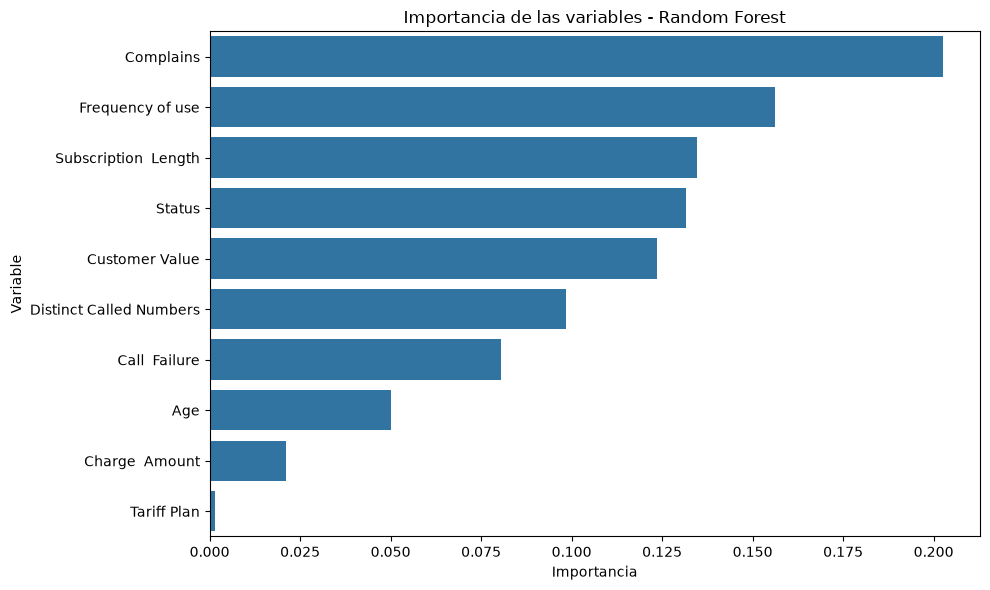

In [31]:
# Gráfico de importancia de variables

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importancias,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de las variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Importancia de las variables

El análisis de importancia de variables del modelo Random Forest permite identificar cuáles características tienen mayor participación en las decisiones realizadas por el modelo.

La variable con mayor importancia fue **Complains**, con un valor de 0.2027. Esto indica que la presencia de reclamos tiene un peso considerable en la clasificación del abandono. Le siguen **Frequency of use**, con 0.1562, y **Subscription Length**, con 0.1345.

También presentan una importancia relevante **Status**, con 0.1315, y **Customer Value**, con 0.1236. Estas variables aportan información relacionada con el comportamiento, permanencia y valor del cliente, por lo que pueden ser útiles para identificar patrones asociados al abandono.

En contraste, **Tariff Plan** presentó una importancia de 0.0015, siendo la variable con menor contribución dentro del modelo. Sin embargo, una importancia baja no significa necesariamente que la variable sea incorrecta o que deba eliminarse automáticamente, ya que su utilidad puede depender de la interacción con otras variables.

Estos resultados aportan interpretabilidad al modelo y permiten relacionar el desempeño predictivo con características concretas de los clientes. Además, pueden servir como apoyo para diseñar estrategias de retención enfocadas en señales tempranas de posible abandono.


In [32]:
from sklearn.metrics import roc_curve

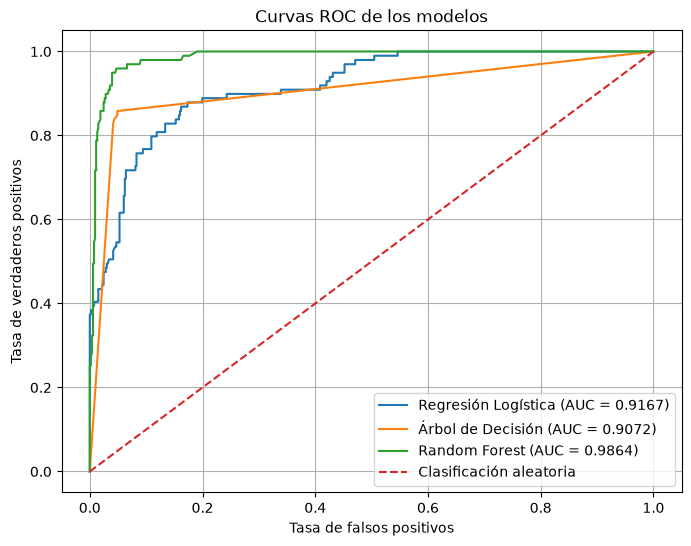

In [33]:
# Curvas ROC de los tres modelos

fpr_logistico, tpr_logistico, _ = roc_curve(
    y_test, y_prob_logistico
)

fpr_arbol, tpr_arbol, _ = roc_curve(
    y_test, y_prob_arbol
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test, y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistico,
    tpr_logistico,
    label=f"Regresión Logística (AUC = {auc_logistico:.4f})"
)

plt.plot(
    fpr_arbol,
    tpr_arbol,
    label=f"Árbol de Decisión (AUC = {auc_arbol:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.title("Curvas ROC de los modelos")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid()
plt.show()

### Selección y justificación del modelo

A partir de la evaluación realizada, se selecciona **Random Forest** como modelo final para el problema de predicción de abandono de clientes.

La selección se fundamenta en los resultados obtenidos sobre el conjunto de prueba. Random Forest alcanzó un Accuracy de **0.9603**, una Precision de **0.9111**, un Recall de **0.8283**, un F1-Score de **0.8677** y un AUC de **0.9864**.

Desde el punto de vista técnico, el modelo presenta un desempeño equilibrado. Su Recall de 0.8283 indica que identifica una proporción elevada de los clientes que realmente abandonaron, mientras que su Precision de 0.9111 indica que la mayoría de los clientes clasificados como posibles casos de abandono pertenecen efectivamente a esa clase. Además, el AUC de 0.9864 muestra una elevada capacidad de discriminación entre las dos clases evaluadas.

La matriz de confusión también proporciona evidencia relevante. Random Forest clasificó correctamente **523 clientes que no abandonaron** y **82 clientes que sí abandonaron**. Al mismo tiempo, presentó **8 falsos positivos** y **17 falsos negativos**. En un contexto de retención, los falsos negativos son especialmente importantes porque representan clientes que abandonaron y que el modelo no logró identificar previamente.

La Regresión Logística presentó un AUC de 0.9167 y una Precision de 0.8367, pero su Recall fue de 0.4141, por lo que dejó sin identificar una proporción mayor de los clientes que realmente abandonaron. El Árbol de Decisión alcanzó un Recall de 0.8384, ligeramente superior al de Random Forest, pero obtuvo una Precision de 0.7830 y un AUC de 0.9072.

Por lo tanto, la elección de Random Forest se basa en el conjunto de métricas y no únicamente en Accuracy. El modelo ofrece un equilibrio favorable entre Precision, Recall, F1-Score y AUC dentro de las pruebas realizadas, además de proporcionar información sobre la importancia relativa de las variables.

### Consideraciones de negocio

El modelo puede utilizarse como herramienta de apoyo para identificar clientes con mayor probabilidad de abandono y priorizar acciones de retención. La predicción no debería utilizarse como una decisión automática sobre el cliente, sino como información adicional para que el área de negocio determine las acciones correspondientes.

Las variables con mayor importancia identificadas por Random Forest fueron **Complains**, **Frequency of use**, **Subscription Length**, **Status** y **Customer Value**. Esta información puede ayudar a enfocar el análisis en señales relacionadas con la experiencia del cliente, su nivel de utilización del servicio, su permanencia y su valor.


## 5. Análisis de límites y riesgos del modelo

**Riesgo de Sobreajuste (Overfitting):** El algoritmo de Árbol de Decisión individual demostró una tendencia al sobreajuste, ya que tiende a memorizar los datos de entrenamiento creando reglas hiper-específicas. Por este motivo, el modelo seleccionado final (Random Forest) mitiga este riesgo de manera óptima al promediar las predicciones de un ensamble de 200 árboles independientes, garantizando la estabilidad y generalización con datos nuevos del negocio.

**Efecto de los Valores Atípicos (Outliers):** Durante la exploración visual se observó que variables como Customer Value o Call Failure presentan distribuciones con un marcado sesgo a la derecha y presencia de valores atípicos (outliers). Al aplicar el escalamiento estándar (StandardScaler), la media y la desviación estándar se ven influenciadas por estos valores, lo que puede distorsionar las distancias. Sin embargo, dado que nuestro modelo final seleccionado es Random Forest, el impacto de los outliers es nulo o mínimo. Los algoritmos basados en árboles de decisión realizan divisiones basadas en umbrales de valor (reglas mayor/menor que) y no se calculan mediante distancias euclidianas, haciéndolos inmunes a las distorsiones por valores extremos.

**Impacto de Datos No Representativos (Data Drift):** El modelo predice basándose estrictamente en patrones de comportamiento históricos. Si la empresa de telecomunicaciones cambia radicalmente su infraestructura de red (reduciendo las caídas de llamadas), lanza planes tarifarios disruptivos o la competencia lanza una oferta agresiva, los datos históricos dejarán de ser representativos. Esto provocará una degradación en el Recall del modelo, por lo que se requiere un monitoreo continuo del entorno del negocio y un reentrenamiento periódico (mínimo trimestral).

## 6. Consideraciones éticas

**Riesgo de sesgo y discriminación:** Al incluir variables como Age (Edad), existe el riesgo latente de que el modelo penalice o catalogue sistemáticamente a ciertos grupos etarios (por ejemplo, adultos mayores o jóvenes) como propensos al abandono. Desde la perspectiva ética del negocio, estos hallazgos se deben utilizar exclusivamente para diseñar incentivos positivos de fidelización (mejorar la atención o dar beneficios) y bajo ninguna circunstancia para restringir servicios, aumentar tarifas de forma punitiva o discriminar a segmentos específicos de la población. El abandono debe tratarse como un problema de insatisfacción del servicio, no como una condición del cliente.

**Transparencia para los Stakeholders:** Los modelos de ensamble como Random Forest actúan como "cajas negras" difíciles de explicar regla por regla. Para garantizar la transparencia ante los directivos y tomadores de decisiones, se ha extraído el gráfico de Importancia de Variables (Feature Importance). De este modo, el negocio puede auditar los criterios del modelo y validar que las decisiones se están tomando por factores lógicos de negocio (como reclamos o baja frecuencia de uso) y no por sesgos arbitrarios.

**Privacidad de los datos:** Los datos utilizados anonimizan la identidad del cliente (no se incluyen nombres, identificaciones ni números telefónicos). Se deben aplicar políticas estrictas de gobierno de datos para asegurar que las predicciones del modelo se almacenen de forma segura y solo sean accesibles por el personal autorizado de retención de clientes.


## 7. Conclusión y Recomendación Final

**Modelo Recomendado y Justificación:** Se concluye que el mejor modelo para implementar es Random Forest. La decisión no se basa únicamente en su alta exactitud (Accuracy: 0.9603), sino en su capacidad para balancear perfectamente la seguridad de sus alertas (Precision: 0.9111) con la capacidad de atrapar a los clientes que realmente se van a ir (Recall: 0.8283). El Área Bajo la Curva ROC (AUC: 0.9864) confirma que el modelo posee una excelente capacidad de discriminación estadística.

**Alineación con Objetivos Estratégicos:** En el negocio del Churn, el error más costoso es el Falso Negativo (creer que el cliente está feliz cuando en realidad se está yendo). Elegir Random Forest sobre la Regresión Logística representa un enorme ahorro financiero: la Regresión Logística deja escapar al 60% de los clientes en riesgo (alto costo de pérdida), mientras que Random Forest permite al equipo de marketing actuar a tiempo en el 83% de los casos reales de fuga, cuidando además el presupuesto al no lanzar ofertas de retención a clientes estables (bajos falsos positivos).

### Siguientes Pasos y Mejoras:
1. Implementar una optimización de hiperparámetros utilizando GridSearchCV para evaluar combinaciones de profundidad máxima (max_depth) y número de estimadores (n_estimators) para intentar incrementar el Recall.

2. Realizar un análisis del ROI combinando las probabilidades de abandono con la variable Customer Value para priorizar de forma automatizada la retención de los clientes de más alto valor para la compañía.
